# Forrester Beta Convergence

This notebook reproduces the Figure-4 layout idea from Plumlee and Joseph (2018) for the multi-output Forrester experiment. It estimates regression coefficients across repeated simulations and compares:

1. MOOGP (`orthogonal=True`)
2. MOGP (`orthogonal=False`)
3. OLS

The configuration cell below lets you switch between the manuscript fast method and the slow dense baseline with fixed `Psi = I`.

In [10]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import csv
import time

import matplotlib.pyplot as plt
import numpy as np

from moogp.datasets import generate_forrester_data
from moogp.forrester_illustration import (
    fit_moogp_forrester,
    get_model_trend_betas_raw,
    get_ols_betas_raw,
)


In [12]:
GP_METHOD = "fast"  # "slow_fixed_psi" (Psi = I) or "fast" 

In [13]:
SAMPLE_SIZES = [25, 50, 100, 200]
N_REPS = 50
BASE_SEED = 20260321
MAXITER = 300

FIXED_PSI = np.eye(3)
TRUE_BETA_LHS_N = 5000
TRUE_BETA_SEED = 20260322
CSV_PATH = RESULTS_DIR / f"forrester_beta_convergence_{GP_METHOD}_ols5000truth.csv"

METHODS = ["MOOGP", "MOGP", "OLS"]
BETA_TYPES = ["intercept", "trend"]
OUTPUTS = [1, 2, 3]
BOX_COLORS = ["#d8a3a7", "#7bb274", "#b39ac9", "#f0a64b"]

if GP_METHOD not in {"slow_fixed_psi", "fast"}:
    raise ValueError(f"Unsupported GP_METHOD={GP_METHOD!r}")

# Raw-x basis: beta0 + beta1 * x on x in [0, 1]
true_beta_data = generate_forrester_data(
    n=TRUE_BETA_LHS_N,
    seed=TRUE_BETA_SEED,
    with_error=False,
)
TRUE_BETAS_RAW = get_ols_betas_raw(true_beta_data["X"], true_beta_data["y"])
TRUE_BETAS_RAW


array([[-1.65492079,  1.67253961, -0.17606337],
       [ 4.21626759,  7.1081338 , -8.37301407]])

In [14]:
def replication_seed(n_train, rep):
    return int(BASE_SEED + 10_000 * n_train + rep)


def generate_training_data(n_train, seed):
    return generate_forrester_data(
        n=n_train,
        seed=seed,
        with_error=True,
        error_per_output=[10.0, 1.0, 0.05],
    )


def get_gp_fit_kwargs():
    if GP_METHOD == "slow_fixed_psi":
        return {"Psi": FIXED_PSI.copy(), "use_fast": False, "learn_Psi": False}
    return {"Psi": None, "use_fast": True, "learn_Psi": False}


def fit_betas_for_replication(data, seed):
    gp_fit_kwargs = get_gp_fit_kwargs()
    moogp, _, _, _ = fit_moogp_forrester(
        n_train=data["X"].shape[0],
        seed=seed,
        orthogonal=True,
        data=data,
        maxiter=MAXITER,
        **gp_fit_kwargs,
    )
    mogp, _, _, _ = fit_moogp_forrester(
        n_train=data["X"].shape[0],
        seed=seed,
        orthogonal=False,
        data=data,
        maxiter=MAXITER,
        **gp_fit_kwargs,
    )
    ols = get_ols_betas_raw(data["X"], data["y"])

    return {
        "MOOGP": get_model_trend_betas_raw(moogp),
        "MOGP": get_model_trend_betas_raw(mogp),
        "OLS": ols,
    }


def collect_results(sample_sizes=SAMPLE_SIZES, n_reps=N_REPS):
    rows = []
    start = time.perf_counter()

    for n_train in sample_sizes:
        for rep in range(n_reps):
            seed = replication_seed(n_train, rep)
            data = generate_training_data(n_train, seed)
            beta_by_method = fit_betas_for_replication(data, seed)

            for method, betas in beta_by_method.items():
                for output_idx in range(3):
                    for beta_idx, beta_name in enumerate(BETA_TYPES):
                        rows.append(
                            {
                                "n_train": n_train,
                                "rep": rep,
                                "seed": seed,
                                "method": method,
                                "output": output_idx + 1,
                                "beta_type": beta_name,
                                "beta_value": float(betas[beta_idx, output_idx]),
                                "true_beta": float(TRUE_BETAS_RAW[beta_idx, output_idx]),
                            }
                        )

        elapsed = time.perf_counter() - start
        print(f"Finished n={n_train} in {elapsed:.1f}s")

    return rows


def write_results_csv(rows, path=CSV_PATH):
    fieldnames = ["n_train", "rep", "seed", "method", "output", "beta_type", "beta_value", "true_beta"]
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def load_results_csv(path=CSV_PATH):
    rows = []
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(
                {
                    "n_train": int(row["n_train"]),
                    "rep": int(row["rep"]),
                    "seed": int(row["seed"]),
                    "method": row["method"],
                    "output": int(row["output"]),
                    "beta_type": row["beta_type"],
                    "beta_value": float(row["beta_value"]),
                    "true_beta": float(row["true_beta"]),
                }
            )
    return rows


def select_beta_values(rows, *, output, method, beta_type):
    grouped = []
    for n_train in SAMPLE_SIZES:
        vals = [
            row["beta_value"]
            for row in rows
            if row["output"] == output and row["method"] == method and row["beta_type"] == beta_type and row["n_train"] == n_train
        ]
        grouped.append(vals)
    return grouped


def summarize_rows(rows, output, beta_type):
    summary = []
    for method in METHODS:
        for n_train in SAMPLE_SIZES:
            vals = [
                row["beta_value"]
                for row in rows
                if row["output"] == output and row["method"] == method and row["beta_type"] == beta_type and row["n_train"] == n_train
            ]
            summary.append(
                {
                    "output": output,
                    "beta_type": beta_type,
                    "method": method,
                    "n_train": n_train,
                    "mean": float(np.mean(vals)),
                    "std": float(np.std(vals)),
                    "true_beta": float(TRUE_BETAS_RAW[BETA_TYPES.index(beta_type), output - 1]),
                }
            )
    return summary


## Run or Load the Experiment

The full experiment is 4 sample sizes × 50 replications × 2 GP fits per replication. The cell below writes the results to a mode-specific CSV and reloads from disk on later runs.

In [15]:
if CSV_PATH.exists():
    rows = load_results_csv(CSV_PATH)
    print(f"GP_METHOD={GP_METHOD}")
    print(f"Loaded {len(rows)} rows from {CSV_PATH}")
else:
    rows = collect_results()
    write_results_csv(rows, CSV_PATH)
    print(f"GP_METHOD={GP_METHOD}")
    print(f"Saved {len(rows)} rows to {CSV_PATH}")

assert len(rows) == len(SAMPLE_SIZES) * N_REPS * len(METHODS) * len(OUTPUTS) * len(BETA_TYPES)
CSV_PATH


Finished n=25 in 38.7s
Finished n=50 in 76.3s
Finished n=100 in 129.8s
Finished n=200 in 248.8s
GP_METHOD=fast
Saved 3600 rows to /Users/evanbarnett/Desktop/Northwestern/Research/moogp-codex-play/results/forrester_beta_convergence_fast_ols5000truth.csv


PosixPath('/Users/evanbarnett/Desktop/Northwestern/Research/moogp-codex-play/results/forrester_beta_convergence_fast_ols5000truth.csv')

In [6]:
summary_output1 = summarize_rows(rows, output=1, beta_type="intercept")
summary_output2 = summarize_rows(rows, output=2, beta_type="intercept")
summary_output3 = summarize_rows(rows, output=3, beta_type="intercept")
summary_output1[:3]


[{'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 25,
  'mean': -1.9140165210985651,
  'std': 1.377534423380214,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 50,
  'mean': -1.584612670588987,
  'std': 0.8863123849322476,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 100,
  'mean': -1.677961918176627,
  'std': 0.6520569039407985,
  'true_beta': -1.6549207883921637}]

In [16]:
paper_rc = {
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "savefig.dpi": 300,
}


def plot_output_figure(rows, output):
    with plt.rc_context(paper_rc):
        fig, axes = plt.subplots(2, 3, figsize=(11.4, 6.2), sharex=True, sharey="row")
        fig.patch.set_facecolor("#f7f5f2")

        for ax in axes.ravel():
            ax.set_facecolor("#f7f5f2")

        for col_idx, method in enumerate(METHODS):
            axes[0, col_idx].set_title(method)

            for row_idx, beta_type in enumerate(BETA_TYPES):
                ax = axes[row_idx, col_idx]
                data = select_beta_values(rows, output=output, method=method, beta_type=beta_type)
                positions = np.arange(1, len(SAMPLE_SIZES) + 1)
                box = ax.boxplot(
                    data,
                    positions=positions,
                    widths=0.7,
                    patch_artist=True,
                    medianprops={"color": "#2f2f2f", "linewidth": 1.3},
                    whiskerprops={"color": "#555555", "linewidth": 1.0},
                    capprops={"color": "#555555", "linewidth": 1.0},
                    flierprops={
                        "marker": "o",
                        "markersize": 3.5,
                        "markerfacecolor": "#666666",
                        "markeredgecolor": "#666666",
                        "alpha": 0.9,
                    },
                )

                for patch, color in zip(box["boxes"], BOX_COLORS):
                    patch.set_facecolor(color)
                    patch.set_edgecolor("#555555")
                    patch.set_linewidth(1.1)

                true_beta = TRUE_BETAS_RAW[row_idx, output - 1]
                ax.axhline(true_beta, color="black", linestyle="--", linewidth=1.2)
                ax.set_xticks(positions)
                ax.set_xticklabels([str(n) for n in SAMPLE_SIZES])

                if col_idx == 0:
                    ax.set_ylabel(r"$\beta_0$" if beta_type == "intercept" else r"$\beta_1$")
                else:
                    ax.tick_params(labelleft=False)
                if row_idx == 1:
                    ax.set_xlabel(r"$n$")

        fig.suptitle(f"Forrester beta recovery: Output {output}", y=0.98)
        fig.tight_layout()
        return fig


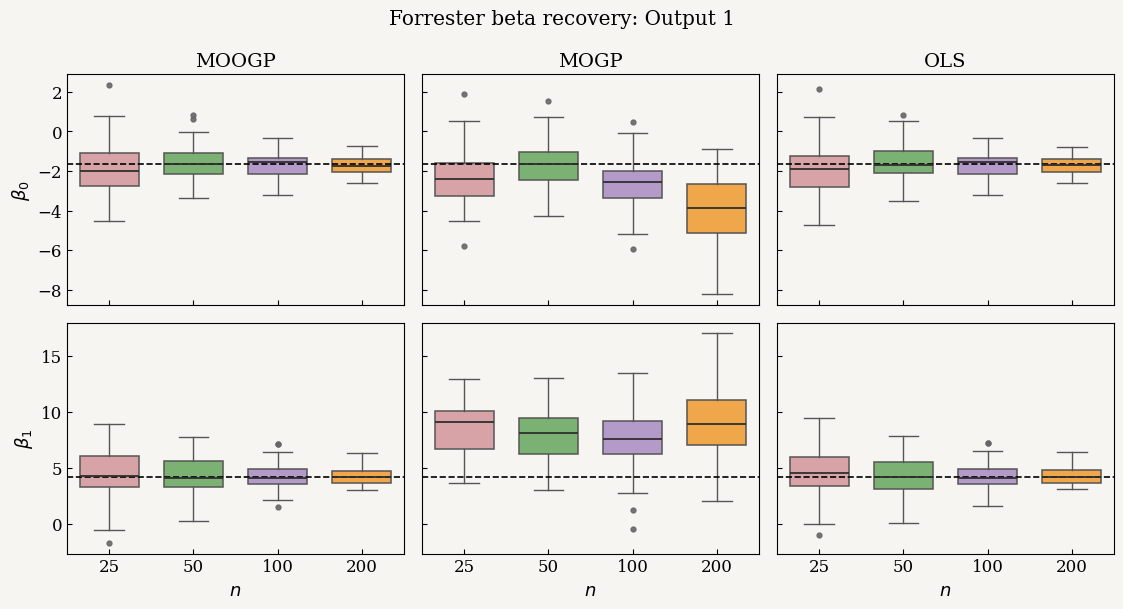

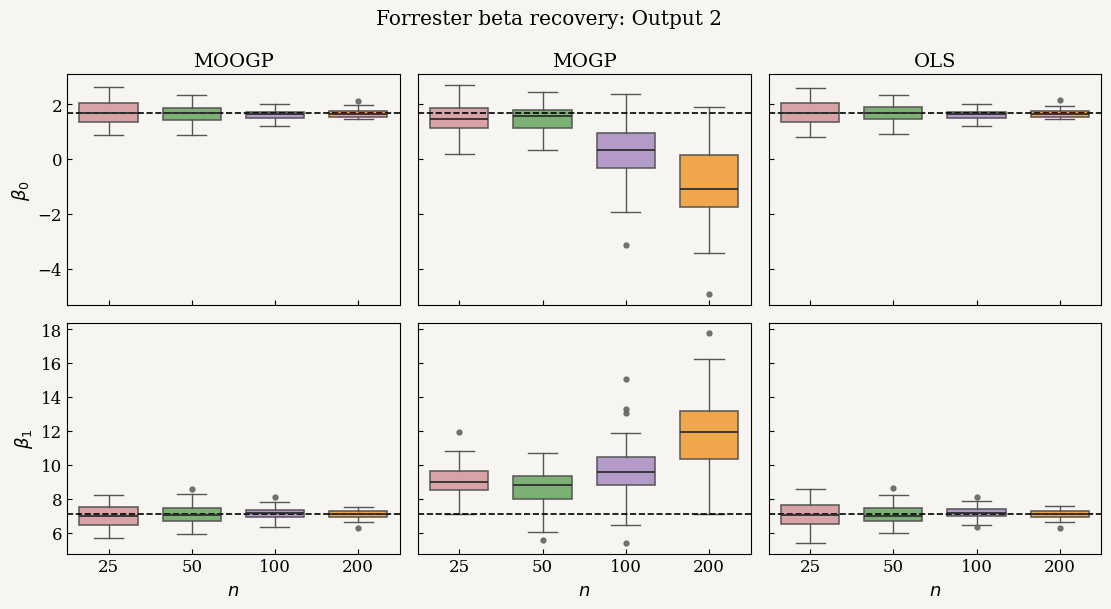

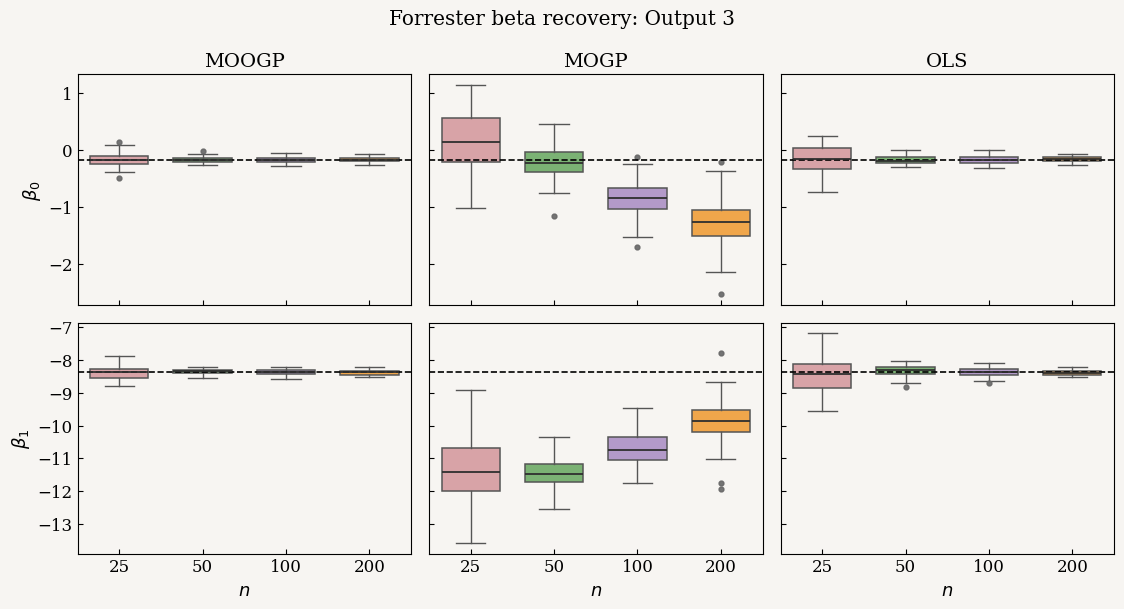

In [17]:
figures = {}
for output in OUTPUTS:
    fig = plot_output_figure(rows, output=output)
    figures[output] = fig
    fig.savefig(RESULTS_DIR / f"forrester_beta_recovery_output{output}_{GP_METHOD}.png", bbox_inches="tight")
    fig.savefig(RESULTS_DIR / f"forrester_beta_recovery_output{output}_{GP_METHOD}.pdf", bbox_inches="tight")

plt.show()


In [9]:
summary_rows = []
for output in OUTPUTS:
    for beta_type in BETA_TYPES:
        summary_rows.extend(summarize_rows(rows, output=output, beta_type=beta_type))

# Quick sanity checks on the saved results
for output in OUTPUTS:
    for beta_type in BETA_TYPES:
        moogp_mean = np.mean([row["mean"] for row in summary_rows if row["output"] == output and row["beta_type"] == beta_type and row["method"] == "MOOGP" and row["n_train"] == 200])
        true_beta = TRUE_BETAS_RAW[BETA_TYPES.index(beta_type), output - 1]
        assert np.isfinite(moogp_mean)
        assert np.isfinite(true_beta)

summary_rows[:6]


[{'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 25,
  'mean': -1.9140165210985651,
  'std': 1.377534423380214,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 50,
  'mean': -1.584612670588987,
  'std': 0.8863123849322476,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 100,
  'mean': -1.677961918176627,
  'std': 0.6520569039407985,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOOGP',
  'n_train': 200,
  'mean': -1.7157942024131756,
  'std': 0.4455831647286504,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOGP',
  'n_train': 25,
  'mean': -2.5184444331231317,
  'std': 1.4977893464648924,
  'true_beta': -1.6549207883921637},
 {'output': 1,
  'beta_type': 'intercept',
  'method': 'MOGP',
  'n_train': 50,
  'mean': -1.947432866607559,
  